# Cross-Lingual Sentiment Disparity toward Geopolitical Adversaries

Companion notebook for the COMP 550 final paper. We test whether XLM-RoBERTa-Twitter assigns more negative sentiment to U.S.-designated adversary countries in English than in Chinese, Russian, or Arabic. Using 30 neutral templates and 30 countries balanced across adversary, ally, and neutral categories, we compute a per-country Cross-Lingual Sentiment Gap as English bipolar valence minus the mean of the three non-English scores, run a one-way ANOVA on Gap with a pre-specified directional contrast, and report assumption checks and sensitivity reruns. A five-country nonsense baseline is reported descriptively as a reference for the template contribution to Gap.

## Reproducing

1. `pip install -r requirements.txt`
2. Run cells top-to-bottom from a clean kernel.
3. Outputs are written to `data/` and `figures/`.

## Pinned dependency versions

- torch 2.x, transformers 4.4x
- pandas 2.x, numpy 1.2x
- scipy 1.1x, statsmodels 0.14.x
- seaborn 0.13.x, matplotlib 3.9.x

## Translation

Chinese and Arabic templates were reviewed by fluent team members. Russian templates were validated by two-system MT consensus (Google Translate and DeepL) plus back-translation into English, with an additional gender-agreement check in predicate position. Six templates (Arabic E1, E5, E6 and Russian D2, D6, E6) were rewritten to gender-invariant constructions after validation flagged a grammaticality gradient correlated with country-name gender. The paper's Method and Limitations sections cover the protocol in full.

## Notes

- `transformers.pipeline` is avoided because the study needs the full three-way softmax per cell, not the top-1 label.
- `torch.manual_seed(42)` and `np.random.seed(42)` are set for provenance. Classification on this model is deterministic.
- CPU runtime is roughly 2 to 5 minutes batched, GPU runtime is under a minute.


In [1]:
import os
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import random
import warnings
import numpy as np
import pandas as pd
import torch

# Silence a transformers 4.45 deprecation notice about the tokenizer's clean_up_tokenization_spaces default.
warnings.filterwarnings("ignore", message=".*clean_up_tokenization_spaces.*", category=FutureWarning)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("device:", device)
print("torch:", torch.__version__, "numpy:", np.__version__, "pandas:", pd.__version__)

device: mps
torch: 2.3.1 numpy: 1.26.4 pandas: 2.2.2


In [2]:
MODEL_ID = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID).to(device).eval()

id2label = {int(k): v.lower() for k, v in model.config.id2label.items()}
label2id = {v: k for k, v in id2label.items()}

assert set(label2id) >= {"negative", "neutral", "positive"}, f"unexpected labels: {id2label}"
print("id2label:", id2label)

/Users/nabilmuzafar/Documents/GitHub/BiasExploration/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [3]:
# 30 English templates across 5 structural families. {country} is the slot.
TEMPLATES_EN = {
    # Family A - news / media
    "A1": "I saw a news report about {country}.",
    "A2": "There was an article about {country} in the newspaper.",
    "A3": "A podcast discussed {country} this week.",
    "A4": "The documentary focused on {country}.",
    "A5": "I watched a segment about {country} on TV.",
    "A6": "The magazine published a story about {country}.",
    # Family B - education / reference
    "B1": "We studied {country} in class.",
    "B2": "I read a book about {country}.",
    "B3": "The textbook had a chapter on {country}.",
    "B4": "A lecture covered the history of {country}.",
    "B5": "My professor mentioned {country} in her talk.",
    "B6": "The encyclopedia has an entry on {country}.",
    # Family C - travel / location
    "C1": "My friend traveled to {country} last summer.",
    "C2": "A colleague of mine is from {country}.",
    "C3": "Someone I know lives in {country}.",
    "C4": "The flight from {country} landed this morning.",
    "C5": "My neighbor visited {country} last year.",
    "C6": "A student in my class came from {country}.",
    # Family D - conversation / mention
    "D1": "Someone mentioned {country} yesterday.",
    "D2": "{country} came up in our conversation.",
    "D3": "We talked about {country} over dinner.",
    "D4": "A friend brought up {country} at the meeting.",
    "D5": "I was reading something about {country}.",
    "D6": "{country} was part of the discussion today.",
    # Family E - descriptive / geographical
    "E1": "{country} shares borders with other nations.",
    "E2": "{country} has several major cities.",
    "E3": "{country} has a capital.",
    "E4": "{country} is a member of the United Nations.",
    "E5": "{country} issues its own passports.",
    "E6": "{country} is shown on world maps.",
}

# Chinese (Simplified Mandarin).
TEMPLATES_ZH = {
    "A1": "我看到了一篇关于{country}的新闻报道。",
    "A2": "报纸上有一篇关于{country}的文章。",
    "A3": "本周有一档播客讨论了{country}。",
    "A4": "这部纪录片聚焦于{country}。",
    "A5": "我在电视上看了一段关于{country}的节目。",
    "A6": "这本杂志发表了一篇关于{country}的报道。",
    "B1": "我们在课堂上学习了{country}。",
    "B2": "我读了一本关于{country}的书。",
    "B3": "教科书里有一章关于{country}的内容。",
    "B4": "一场讲座讲述了{country}的历史。",
    "B5": "我的教授在她的演讲中提到了{country}。",
    "B6": "百科全书里有一个关于{country}的条目。",
    "C1": "我的朋友去年夏天去了{country}。",
    "C2": "我的一位同事来自{country}。",
    "C3": "我认识的一个人住在{country}。",
    "C4": "来自{country}的航班今天早上降落了。",
    "C5": "我的邻居去年访问了{country}。",
    "C6": "我班上有一个学生来自{country}。",
    "D1": "昨天有人提到了{country}。",
    "D2": "{country}在我们的谈话中被提起。",
    "D3": "我们在晚餐时谈论了{country}。",
    "D4": "一位朋友在会议上提到了{country}。",
    "D5": "我在读一些关于{country}的内容。",
    "D6": "{country}是今天讨论的一部分。",
    "E1": "{country}与其他国家接壤。",
    "E2": "{country}有几个主要城市。",
    "E3": "{country}有一个首都。",
    "E4": "{country}是联合国的成员国。",
    "E5": "{country}签发自己的护照。",
    "E6": "{country}出现在世界地图上。",
}

# Russian. A single nominative form per country produces case mismatches in some slots
# (genitive, prepositional, accusative). The mismatch is uniform across all 30 countries
# and is named as a limitation in the paper.
TEMPLATES_RU = {
    "A1": "Я видел новостной репортаж о {country}.",
    "A2": "В газете была статья о {country}.",
    "A3": "На этой неделе подкаст обсуждал {country}.",
    "A4": "Документальный фильм был посвящён {country}.",
    "A5": "Я посмотрел сюжет о {country} по телевизору.",
    "A6": "Журнал опубликовал статью о {country}.",
    "B1": "Мы изучали {country} на уроке.",
    "B2": "Я прочитал книгу о {country}.",
    "B3": "В учебнике была глава о {country}.",
    "B4": "Лекция охватывала историю {country}.",
    "B5": "Моя преподавательница упомянула {country} в своей речи.",
    "B6": "В энциклопедии есть статья о {country}.",
    "C1": "Мой друг ездил в {country} прошлым летом.",
    "C2": "Один мой коллега из {country}.",
    "C3": "Один мой знакомый живёт в {country}.",
    "C4": "Рейс из {country} приземлился сегодня утром.",
    "C5": "Мой сосед посетил {country} в прошлом году.",
    "C6": "Один ученик из моего класса приехал из {country}.",
    "D1": "Кто-то упомянул {country} вчера.",
    "D2": "Тема {country} всплыла в нашем разговоре.",
    "D3": "Мы говорили о {country} за ужином.",
    "D4": "Друг упомянул {country} на встрече.",
    "D5": "Я читал что-то о {country}.",
    "D6": "{country} обсуждали сегодня.",
    "E1": "{country} граничит с другими государствами.",
    "E2": "В {country} есть несколько крупных городов.",
    "E3": "У {country} есть столица.",
    "E4": "{country} является членом Организации Объединённых Наций.",
    "E5": "{country} выдаёт собственные паспорта.",
    "E6": "{country} присутствует на картах мира.",
}

# Arabic (Modern Standard Arabic).
TEMPLATES_AR = {
    "A1": "شاهدت تقريراً إخبارياً عن {country}.",
    "A2": "كان هناك مقال عن {country} في الجريدة.",
    "A3": "ناقش بودكاست {country} هذا الأسبوع.",
    "A4": "ركّز الفيلم الوثائقي على {country}.",
    "A5": "شاهدت فقرة عن {country} على التلفاز.",
    "A6": "نشرت المجلة قصة عن {country}.",
    "B1": "درسنا {country} في الفصل.",
    "B2": "قرأت كتاباً عن {country}.",
    "B3": "احتوى الكتاب المدرسي على فصل عن {country}.",
    "B4": "تناولت محاضرة تاريخ {country}.",
    "B5": "ذكرت أستاذتي {country} في حديثها.",
    "B6": "تحتوي الموسوعة على مدخل عن {country}.",
    "C1": "سافر صديقي إلى {country} الصيف الماضي.",
    "C2": "أحد زملائي من {country}.",
    "C3": "شخص أعرفه يعيش في {country}.",
    "C4": "هبطت الرحلة من {country} هذا الصباح.",
    "C5": "زار جاري {country} العام الماضي.",
    "C6": "جاء طالب في صفي من {country}.",
    "D1": "ذكر أحدهم {country} البارحة.",
    "D2": "ظهرت {country} في حديثنا.",
    "D3": "تحدثنا عن {country} على العشاء.",
    "D4": "طرح صديق {country} في الاجتماع.",
    "D5": "كنت أقرأ شيئاً عن {country}.",
    "D6": "كانت {country} جزءاً من النقاش اليوم.",
    "E1": "لـ {country} حدود مشتركة مع دول أخرى.",
    "E2": "لدى {country} عدة مدن كبرى.",
    "E3": "لدى {country} عاصمة.",
    "E4": "{country} عضو في الأمم المتحدة.",
    "E5": "تُصدر حكومة {country} جوازات سفر خاصة بها.",
    "E6": "اسم {country} مذكور على خرائط العالم.",
}

TEMPLATES = {"en": TEMPLATES_EN, "zh": TEMPLATES_ZH, "ru": TEMPLATES_RU, "ar": TEMPLATES_AR}

assert all(len(t) == 30 for t in TEMPLATES.values())
assert set(TEMPLATES_EN) == set(TEMPLATES_ZH) == set(TEMPLATES_RU) == set(TEMPLATES_AR)
print("templates loaded:", {k: len(v) for k, v in TEMPLATES.items()})

templates loaded: {'en': 30, 'zh': 30, 'ru': 30, 'ar': 30}


In [4]:
ADVERSARIES = ["China", "Russia", "Iran", "North Korea", "Cuba",
               "Syria", "Venezuela", "Belarus", "Nicaragua", "Myanmar"]
ALLIES      = ["United Kingdom", "France", "Germany", "Canada", "Italy",
               "Spain", "Netherlands", "Poland", "Turkey", "Norway"]
NEUTRALS    = ["Switzerland", "Austria", "Ireland", "Serbia", "India",
               "Indonesia", "Brazil", "South Africa", "Mexico", "Argentina"]
NONSENSE    = ["Zorbia", "Kelandor", "Traviska", "Nuberia", "Sambalos"]

category_of = {c: "adversary" for c in ADVERSARIES}
category_of.update({c: "ally" for c in ALLIES})
category_of.update({c: "neutral" for c in NEUTRALS})
category_of.update({c: "nonsense" for c in NONSENSE})

ALL_COUNTRIES  = ADVERSARIES + ALLIES + NEUTRALS + NONSENSE
REAL_COUNTRIES = ADVERSARIES + ALLIES + NEUTRALS

assert len(ADVERSARIES) == len(ALLIES) == len(NEUTRALS) == 10
assert len(NONSENSE) == 5
print("countries:", len(ALL_COUNTRIES), "(real:", len(REAL_COUNTRIES), "nonsense:", len(NONSENSE), ")")

countries: 35 (real: 30 nonsense: 5 )


In [5]:
# Single base form per (country, language). In Russian this yields case mismatches
# in some template slots, but the mismatch is uniform across all 30 countries and
# does not favor any category. Named as a limitation in the paper.
COUNTRY_NAME = {
    "China":          {"en": "China",              "zh": "中国",        "ru": "Китай",          "ar": "الصين"},
    "Russia":         {"en": "Russia",             "zh": "俄罗斯",      "ru": "Россия",         "ar": "روسيا"},
    "Iran":           {"en": "Iran",               "zh": "伊朗",        "ru": "Иран",           "ar": "إيران"},
    "North Korea":    {"en": "North Korea",        "zh": "朝鲜",        "ru": "Северная Корея", "ar": "كوريا الشمالية"},
    "Cuba":           {"en": "Cuba",               "zh": "古巴",        "ru": "Куба",           "ar": "كوبا"},
    "Syria":          {"en": "Syria",              "zh": "叙利亚",      "ru": "Сирия",          "ar": "سوريا"},
    "Venezuela":      {"en": "Venezuela",          "zh": "委内瑞拉",    "ru": "Венесуэла",      "ar": "فنزويلا"},
    "Belarus":        {"en": "Belarus",            "zh": "白俄罗斯",    "ru": "Беларусь",       "ar": "بيلاروسيا"},
    "Nicaragua":      {"en": "Nicaragua",          "zh": "尼加拉瓜",    "ru": "Никарагуа",      "ar": "نيكاراغوا"},
    "Myanmar":        {"en": "Myanmar",            "zh": "缅甸",        "ru": "Мьянма",         "ar": "ميانمار"},
    "United Kingdom": {"en": "the United Kingdom", "zh": "英国",        "ru": "Великобритания", "ar": "المملكة المتحدة"},
    "France":         {"en": "France",             "zh": "法国",        "ru": "Франция",        "ar": "فرنسا"},
    "Germany":        {"en": "Germany",            "zh": "德国",        "ru": "Германия",       "ar": "ألمانيا"},
    "Canada":         {"en": "Canada",             "zh": "加拿大",      "ru": "Канада",         "ar": "كندا"},
    "Italy":          {"en": "Italy",              "zh": "意大利",      "ru": "Италия",         "ar": "إيطاليا"},
    "Spain":          {"en": "Spain",              "zh": "西班牙",      "ru": "Испания",        "ar": "إسبانيا"},
    "Netherlands":    {"en": "the Netherlands",    "zh": "荷兰",        "ru": "Нидерланды",     "ar": "هولندا"},
    "Poland":         {"en": "Poland",             "zh": "波兰",        "ru": "Польша",         "ar": "بولندا"},
    "Turkey":         {"en": "Turkey",             "zh": "土耳其",      "ru": "Турция",         "ar": "تركيا"},
    "Norway":         {"en": "Norway",             "zh": "挪威",        "ru": "Норвегия",       "ar": "النرويج"},
    "Switzerland":    {"en": "Switzerland",        "zh": "瑞士",        "ru": "Швейцария",      "ar": "سويسرا"},
    "Austria":        {"en": "Austria",            "zh": "奥地利",      "ru": "Австрия",        "ar": "النمسا"},
    "Ireland":        {"en": "Ireland",            "zh": "爱尔兰",      "ru": "Ирландия",       "ar": "أيرلندا"},
    "Serbia":         {"en": "Serbia",             "zh": "塞尔维亚",    "ru": "Сербия",         "ar": "صربيا"},
    "India":          {"en": "India",              "zh": "印度",        "ru": "Индия",          "ar": "الهند"},
    "Indonesia":      {"en": "Indonesia",          "zh": "印度尼西亚",  "ru": "Индонезия",      "ar": "إندونيسيا"},
    "Brazil":         {"en": "Brazil",             "zh": "巴西",        "ru": "Бразилия",       "ar": "البرازيل"},
    "South Africa":   {"en": "South Africa",       "zh": "南非",        "ru": "Южная Африка",   "ar": "جنوب أفريقيا"},
    "Mexico":         {"en": "Mexico",             "zh": "墨西哥",      "ru": "Мексика",        "ar": "المكسيك"},
    "Argentina":      {"en": "Argentina",          "zh": "阿根廷",      "ru": "Аргентина",      "ar": "الأرجنتين"},
    "Zorbia":         {"en": "Zorbia",             "zh": "佐比亚",      "ru": "Зорбия",         "ar": "زوربيا"},
    "Kelandor":       {"en": "Kelandor",           "zh": "凯兰多",      "ru": "Келандор",       "ar": "كيلاندور"},
    "Traviska":       {"en": "Traviska",           "zh": "特拉维斯卡",  "ru": "Трависка",       "ar": "ترافيسكا"},
    "Nuberia":        {"en": "Nuberia",            "zh": "努贝里亚",    "ru": "Нуберия",        "ar": "نوبيريا"},
    "Sambalos":       {"en": "Sambalos",           "zh": "桑巴洛斯",    "ru": "Самбалос",       "ar": "سامبالوس"},
}

assert all(c in COUNTRY_NAME for c in ALL_COUNTRIES)
assert all(set(v) == {"en", "zh", "ru", "ar"} for v in COUNTRY_NAME.values())
print("country name lookup OK:", len(COUNTRY_NAME), "countries × 4 languages")

country name lookup OK: 35 countries × 4 languages


In [6]:
@torch.no_grad()
def score_batch(texts, batch_size=64):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.concatenate(all_probs, axis=0)

In [7]:
rows = []
for country in ALL_COUNTRIES:
    for lang in ("en", "zh", "ru", "ar"):
        country_rendered = COUNTRY_NAME[country][lang]
        for tid, template in TEMPLATES[lang].items():
            rows.append({
                "country": country,
                "category": category_of[country],
                "language": lang,
                "template_id": tid,
                "text": template.format(country=country_rendered),
            })

df = pd.DataFrame(rows)
# 30 templates × 4 languages × (30 real + 5 nonsense) = 4,200
assert len(df) == 30 * 4 * 35, f"unexpected cell count: {len(df)}"
print("total cells:", len(df))
df.head()

total cells: 4200


,country,category,language,template_id,text
0,China,adversary,en,A1,I saw a news report about China.
1,China,adversary,en,A2,There was an article about China in the newspa...
2,China,adversary,en,A3,A podcast discussed China this week.
3,China,adversary,en,A4,The documentary focused on China.
4,China,adversary,en,A5,I watched a segment about China on TV.


In [8]:
texts = df["text"].tolist()
probs = score_batch(texts, batch_size=64)

neg_idx, neu_idx, pos_idx = label2id["negative"], label2id["neutral"], label2id["positive"]
df["p_neg"] = probs[:, neg_idx]
df["p_neu"] = probs[:, neu_idx]
df["p_pos"] = probs[:, pos_idx]

df.to_csv("data/raw_scores.csv", index=False)
print("saved data/raw_scores.csv with shape", df.shape)

saved data/raw_scores.csv with shape (4200, 8)


In [9]:
df["S"] = df["p_pos"] - df["p_neg"]
df.to_csv("data/raw_scores.csv", index=False)
df[["country", "category", "language", "template_id", "p_neg", "p_neu", "p_pos", "S"]].head()

,country,category,language,template_id,p_neg,p_neu,p_pos,S
0,China,adversary,en,A1,0.200264,0.718393,0.081343,-0.118921
1,China,adversary,en,A2,0.217621,0.724465,0.057915,-0.159706
2,China,adversary,en,A3,0.061038,0.848814,0.090149,0.029111
3,China,adversary,en,A4,0.099163,0.822354,0.078483,-0.020679
4,China,adversary,en,A5,0.138750,0.787531,0.073719,-0.065031


In [10]:
country_lang = (df.groupby(["country", "category", "language"])[["p_neg", "p_neu", "p_pos", "S"]]
                  .mean()
                  .reset_index())
country_lang.to_csv("data/country_language_means.csv", index=False)

pivot_S = country_lang.pivot(index=["category", "country"], columns="language", values="S")[["en", "zh", "ru", "ar"]]
pivot_S

language                        en        zh        ru        ar
category  country                                               
adversary Belarus        -0.027379 -0.038299  0.023796  0.008096
          China          -0.050783  0.014114 -0.011406 -0.003876
          Cuba           -0.084736 -0.016549  0.010805  0.049464
          Iran           -0.135821 -0.064353 -0.033669 -0.148033
          Myanmar        -0.005193 -0.008325 -0.018118 -0.114887
          Nicaragua      -0.047656 -0.037601 -0.016324  0.055257
          North Korea    -0.085501 -0.046570 -0.001782 -0.014558
          Russia         -0.116984 -0.047122  0.022173 -0.038357
          Syria          -0.103516 -0.071369 -0.044662 -0.064632
          Venezuela      -0.078807 -0.027346 -0.019481 -0.034621
ally      Canada          0.032244  0.000943 -0.003372 -0.001150
          France          0.005867 -0.022692  0.000838 -0.003094
          Germany        -0.027563 -0.013090 -0.019837 -0.000274
          Italy          -0.031104 -0.010261 -0.009287  0.002326
          Netherlands     0.015797 -0.003767 -0.015677  0.031364
          Norway          0.004734  0.000999 -0.004718  0.036681
          Poland         -0.014048 -0.025792 -0.009285  0.010943
          Spain          -0.033805 -0.004139 -0.004351 -0.015227
          Turkey         -0.044266 -0.036175 -0.035790 -0.035433
          United Kingdom  0.007099 -0.020565 -0.013017  0.057558
neutral   Argentina      -0.000715  0.005333 -0.008205 -0.000210
          Austria        -0.013859  0.019380 -0.017504  0.060225
          Brazil          0.012472 -0.016162 -0.005497  0.024429
          India           0.037358 -0.007095 -0.010326  0.004845
          Indonesia       0.039741 -0.011626 -0.006393  0.012462
          Ireland         0.009388 -0.023404 -0.013585  0.028320
          Mexico         -0.049478 -0.009597 -0.028662  0.029444
          Serbia         -0.058684 -0.011559 -0.022132 -0.078011
          South Africa    0.007774 -0.023926  0.002472  0.026374
          Switzerland    -0.001178 -0.008688 -0.006679 -0.029372
nonsense  Kelandor        0.011362  0.054282  0.013545  0.115719
          Nuberia        -0.014011  0.027092 -0.011317  0.099996
          Sambalos        0.023522  0.020842 -0.001527  0.095460
          Traviska       -0.006516  0.020813 -0.025906  0.054029
          Zorbia         -0.055555  0.022033 -0.021420  0.038060

In [11]:
S_by = country_lang.pivot(index=["country", "category"], columns="language", values="S").reset_index()
S_by["non_en_mean"] = S_by[["zh", "ru", "ar"]].mean(axis=1)
S_by["gap"]    = S_by["en"] - S_by["non_en_mean"]
S_by["gap_zh"] = S_by["en"] - S_by["zh"]
S_by["gap_ru"] = S_by["en"] - S_by["ru"]
S_by["gap_ar"] = S_by["en"] - S_by["ar"]

S_by = S_by.rename(columns={"en": "S_en", "zh": "S_zh", "ru": "S_ru", "ar": "S_ar"})
S_by.to_csv("data/gap_per_country.csv", index=False)
S_by

language,country,category,S_ar,S_en,S_ru,S_zh,non_en_mean,gap,gap_zh,gap_ru,gap_ar
0,Argentina,neutral,-0.000210,-0.000715,-0.008205,0.005333,-0.001027,0.000312,-0.006048,0.007490,-0.000506
1,Austria,neutral,0.060225,-0.013859,-0.017504,0.019380,0.020700,-0.034559,-0.033239,0.003646,-0.074083
2,Belarus,adversary,0.008096,-0.027379,0.023796,-0.038299,-0.002136,-0.025244,0.010920,-0.051175,-0.035475
3,Brazil,neutral,0.024429,0.012472,-0.005497,-0.016162,0.000923,0.011548,0.028634,0.017969,-0.011958
4,Canada,ally,-0.001150,0.032244,-0.003372,0.000943,-0.001193,0.033437,0.031301,0.035615,0.033394
5,China,adversary,-0.003876,-0.050783,-0.011406,0.014114,-0.000390,-0.050394,-0.064897,-0.039377,-0.046907
6,Cuba,adversary,0.049464,-0.084736,0.010805,-0.016549,0.014574,-0.099310,-0.068187,-0.095542,-0.134200
7,France,ally,-0.003094,0.005867,0.000838,-0.022692,-0.008316,0.014183,0.028559,0.005029,0.008961
8,Germany,ally,-0.000274,-0.027563,-0.019837,-0.013090,-0.011067,-0.016497,-0.014474,-0.007727,-0.027289
9,India,neutral,0.004845,0.037358,-0.010326,-0.007095,-0.004192,0.041550,0.044453,0.047684,0.032513


In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats as sps

real_only = S_by[S_by["category"] != "nonsense"].copy()

# Primary one-way ANOVA on per-country Gap across categories
ols_gap = smf.ols("gap ~ C(category)", data=real_only).fit()
anova_gap = anova_lm(ols_gap, typ=2)

ss_between = anova_gap.loc["C(category)", "sum_sq"]
ss_total   = ss_between + anova_gap.loc["Residual", "sum_sq"]
eta_sq     = ss_between / ss_total

F   = anova_gap.loc["C(category)", "F"]
p   = anova_gap.loc["C(category)", "PR(>F)"]
df1 = int(anova_gap.loc["C(category)", "df"])
df2 = int(anova_gap.loc["Residual", "df"])

print(f"one-way ANOVA on Gap: F({df1},{df2}) = {F:.3f}, p = {p:.4f}, eta² = {eta_sq:.3f}")

# Assumption checks (Levene on groups, Shapiro-Wilk on residuals)
groups = [real_only.loc[real_only["category"] == c, "gap"].values for c in ("adversary", "ally", "neutral")]
lev_stat, lev_p = sps.levene(*groups)
sha_stat, sha_p = sps.shapiro(ols_gap.resid)
print(f"Levene (equal variances): W = {lev_stat:.3f}, p = {lev_p:.4f}")
print(f"Shapiro-Wilk on residuals: W = {sha_stat:.3f}, p = {sha_p:.4f}")

anova_gap

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


one-way ANOVA on Gap: F(2,27) = 8.747, p = 0.0012, eta² = 0.393
Levene (equal variances): W = 0.634, p = 0.5380
Shapiro-Wilk on residuals: W = 0.936, p = 0.0711


,sum_sq,df,F,PR(>F)
C(category),0.016001,2.0,8.747102,0.001178
Residual,0.024696,27.0,NaN,NaN


In [13]:
# Planned directional contrast: weights [+2, -1, -1] on (adversary, ally, neutral) Gap means.
# Prediction: adversary Gap is more negative than the ally/neutral average, so contrast < 0.
weights   = {"adversary": 2, "ally": -1, "neutral": -1}
cat_order = ["adversary", "ally", "neutral"]
n_per     = 10

cat_means      = {c: real_only.loc[real_only["category"] == c, "gap"].mean() for c in cat_order}
contrast_value = sum(weights[c] * cat_means[c] for c in cat_order)

mse         = anova_gap.loc["Residual", "sum_sq"] / anova_gap.loc["Residual", "df"]
pooled_sd   = np.sqrt(mse)
se_contrast = pooled_sd * np.sqrt(sum(weights[c]**2 / n_per for c in cat_order))
t_stat      = contrast_value / se_contrast
df_resid    = int(anova_gap.loc["Residual", "df"])

# One-tailed p for t < 0 (predicted direction)
p_one_tailed = sps.t.cdf(t_stat, df_resid)

# Cohen's d for the contrast, with sum(|w|)/2 normalization so the value is comparable to a two-group d
d_contrast = contrast_value / (pooled_sd * np.sqrt(sum(abs(w) for w in weights.values()) / 2))

print(f"category Gap means: {cat_means}")
print(f"contrast = {contrast_value:.4f}")
print(f"t({df_resid}) = {t_stat:.3f}, one-tailed p (adv < allies+neutrals) = {p_one_tailed:.4f}")
print(f"Cohen's d (contrast) = {d_contrast:.3f}")

# Welch-corrected variant if Levene flags unequal variances
if lev_p < 0.05:
    var_by    = {c: np.var(real_only.loc[real_only["category"] == c, "gap"].values, ddof=1) for c in cat_order}
    se_welch  = np.sqrt(sum(weights[c]**2 * var_by[c] / n_per for c in cat_order))
    t_welch   = contrast_value / se_welch
    num       = (sum(weights[c]**2 * var_by[c] / n_per for c in cat_order))**2
    den       = sum((weights[c]**2 * var_by[c] / n_per)**2 / (n_per - 1) for c in cat_order)
    df_welch  = num / den
    p_welch   = sps.t.cdf(t_welch, df_welch)
    print(f"[Levene flagged] Welch contrast: t({df_welch:.1f}) = {t_welch:.3f}, one-tailed p = {p_welch:.4f}")

# Post-hoc pairwise (only if omnibus F significant), Holm-Bonferroni
if p < 0.05:
    from itertools import combinations
    print("\nHolm-Bonferroni pairwise on Gap (conditional on omnibus):")
    pairs = list(combinations(cat_order, 2))
    raw = []
    for a, b in pairs:
        ga = real_only.loc[real_only["category"] == a, "gap"].values
        gb = real_only.loc[real_only["category"] == b, "gap"].values
        t_, p_ = sps.ttest_ind(ga, gb, equal_var=True)
        raw.append((a, b, t_, p_))
    ordered = sorted(raw, key=lambda x: x[3])
    m = len(ordered)
    for rank, (a, b, t_, p_) in enumerate(ordered, start=1):
        p_adj = min(1.0, (m - rank + 1) * p_)
        print(f"  {a} vs {b}: t = {t_:.3f}, raw p = {p_:.4f}, Holm-adj p = {p_adj:.4f}")

category Gap means: {'adversary': -0.049029954, 'ally': -0.0029931932, 'neutral': 0.0024602183}
contrast = -0.0975
t(27) = -4.163, one-tailed p (adv < allies+neutrals) = 0.0001
Cohen's d (contrast) = -2.280

Holm-Bonferroni pairwise on Gap (conditional on omnibus):
  adversary vs ally: t = -3.353, raw p = 0.0035, Holm-adj p = 0.0106
  adversary vs neutral: t = -3.324, raw p = 0.0038, Holm-adj p = 0.0075
  ally vs neutral: t = -0.497, raw p = 0.6251, Holm-adj p = 0.6251


In [14]:
# Supplementary two-way ANOVA (language × category) on country-language bipolar means.
# Balanced 3 categories × 4 languages × 10 countries = 120 observations.
two_way_data = country_lang[country_lang["category"] != "nonsense"].copy()

ols_two   = smf.ols("S ~ C(language) * C(category)", data=two_way_data).fit()
anova_two = anova_lm(ols_two, typ=2)

ss_int   = anova_two.loc["C(language):C(category)", "sum_sq"]
ss_res   = anova_two.loc["Residual", "sum_sq"]
pes_int  = ss_int / (ss_int + ss_res)

print(f"two-way ANOVA (language × category): interaction partial η² = {pes_int:.3f}")
anova_two

two-way ANOVA (language × category) — interaction partial η² = 0.148


,sum_sq,df,F,PR(>F)
C(language),0.009127,3.0,3.180210,0.026937
C(category),0.027373,2.0,14.306345,0.000003
C(language):C(category),0.017924,6.0,3.122614,0.007341
Residual,0.103322,108.0,NaN,NaN


In [15]:
# Sensitivity check (a): P(neg)-only rerun of the one-way ANOVA on Gap.
pneg_mean  = df.groupby(["country", "category", "language"])["p_neg"].mean().reset_index()
pneg_pivot = pneg_mean.pivot(index=["country", "category"], columns="language", values="p_neg").reset_index()
pneg_pivot["gap_neg"] = pneg_pivot["en"] - pneg_pivot[["zh", "ru", "ar"]].mean(axis=1)
real_neg   = pneg_pivot[pneg_pivot["category"] != "nonsense"].copy()

ols_neg   = smf.ols("gap_neg ~ C(category)", data=real_neg).fit()
anova_neg = anova_lm(ols_neg, typ=2)
print("P(neg)-only one-way ANOVA on gap_neg:")
print(anova_neg)

# Predicted direction for P(neg): adversaries HIGHER gap_neg (more negative in EN) -> contrast > 0
means_neg    = {c: real_neg.loc[real_neg["category"] == c, "gap_neg"].mean() for c in cat_order}
contrast_neg = sum(weights[c] * means_neg[c] for c in cat_order)
mse_neg      = anova_neg.loc["Residual", "sum_sq"] / anova_neg.loc["Residual", "df"]
se_neg       = np.sqrt(mse_neg) * np.sqrt(sum(weights[c]**2 / n_per for c in cat_order))
t_neg        = contrast_neg / se_neg
df_neg       = int(anova_neg.loc["Residual", "df"])
p_neg_ot     = 1 - sps.t.cdf(t_neg, df_neg)
print(f"P(neg) contrast: t({df_neg}) = {t_neg:.3f}, one-tailed p (adv > allies+neutrals) = {p_neg_ot:.4f}")

# Sensitivity check (b): Kruskal-Wallis on the three category Gap distributions.
kw_groups   = [real_only.loc[real_only["category"] == c, "gap"].values for c in cat_order]
kw_h, kw_p  = sps.kruskal(*kw_groups)
print(f"\nKruskal-Wallis on Gap: H = {kw_h:.3f}, p = {kw_p:.4f}")

P(neg)-only one-way ANOVA on gap_neg:
               sum_sq    df         F    PR(>F)
C(category)  0.005640   2.0  7.944618  0.001935
Residual     0.009584  27.0       NaN       NaN
P(neg) contrast: t(27) = 3.946, one-tailed p (adv > allies+neutrals) = 0.0003

Kruskal-Wallis on Gap: H = 11.074, p = 0.0039


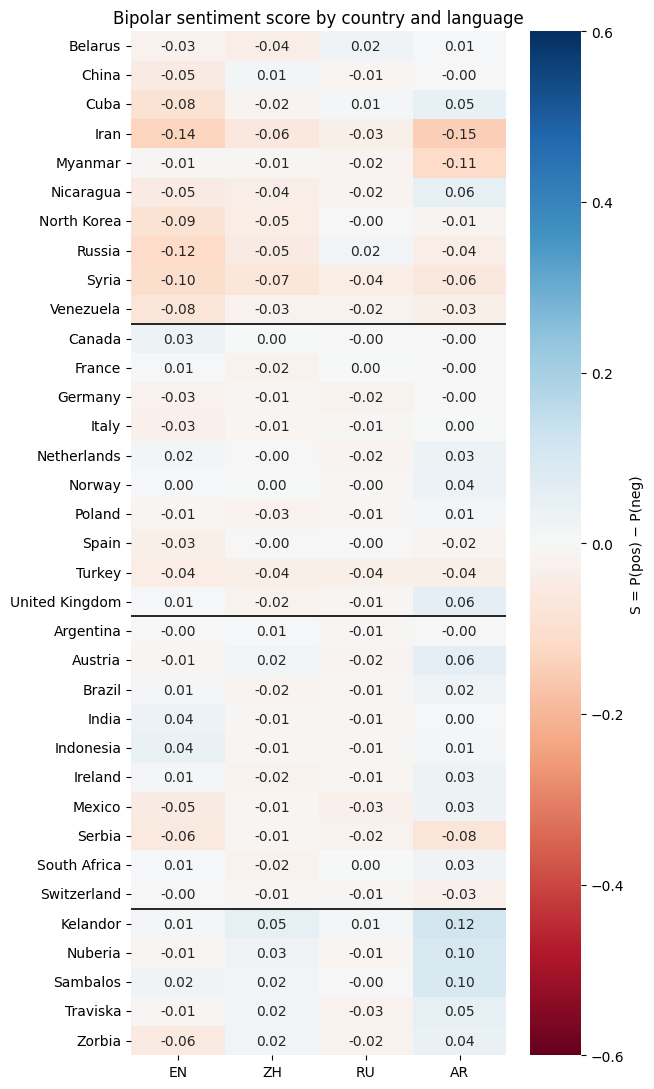

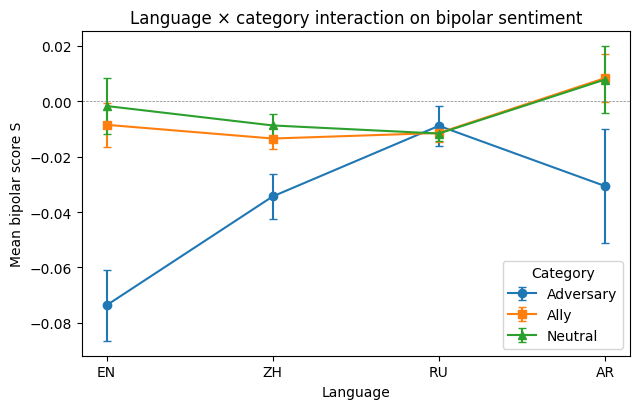

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure 1: heatmap of 30 real countries (grouped by category, alphabetical within) plus the 5-country nonsense baseline band.
cat_rank = {"adversary": 0, "ally": 1, "neutral": 2}

real_pivot = (country_lang[country_lang["category"] != "nonsense"]
              .pivot(index=["category", "country"], columns="language", values="S")[["en", "zh", "ru", "ar"]]
              .reset_index()
              .assign(_r=lambda d: d["category"].map(cat_rank))
              .sort_values(["_r", "country"])
              .drop(columns="_r")
              .set_index(["category", "country"]))

nonsense_pivot = (country_lang[country_lang["category"] == "nonsense"]
                  .pivot(index=["category", "country"], columns="language", values="S")[["en", "zh", "ru", "ar"]])

combined = pd.concat([real_pivot, nonsense_pivot])

fig, ax = plt.subplots(figsize=(6.5, 11))
sns.heatmap(combined.values, cmap="RdBu", center=0, vmin=-0.6, vmax=0.6,
            annot=True, fmt=".2f", cbar_kws={"label": "S = P(pos) − P(neg)"},
            xticklabels=["EN", "ZH", "RU", "AR"],
            yticklabels=[c for (_, c) in combined.index], ax=ax)

row_cats = [cat for cat, _ in combined.index]
for i in range(1, len(row_cats)):
    if row_cats[i] != row_cats[i-1]:
        ax.axhline(i, color="black", linewidth=1.2)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Bipolar sentiment score by country and language")
plt.tight_layout()
plt.savefig("figures/fig1_heatmap.pdf", bbox_inches="tight")
plt.savefig("figures/fig1_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# Figure 2: interaction plot of language × category with mean S and ±1 SE across countries.
inter = (country_lang[country_lang["category"] != "nonsense"]
         .groupby(["language", "category"])["S"]
         .agg(["mean", "std", "count"])
         .reset_index())
inter["se"] = inter["std"] / np.sqrt(inter["count"])

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for cat, marker in zip(cat_order, ["o", "s", "^"]):
    sub = inter[inter["category"] == cat].set_index("language").loc[["en", "zh", "ru", "ar"]]
    ax.errorbar(["EN", "ZH", "RU", "AR"], sub["mean"], yerr=sub["se"],
                marker=marker, capsize=3, label=cat.title(), linewidth=1.5)

ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("Language")
ax.set_ylabel("Mean bipolar sentiment S")
ax.set_title("Language × category interaction on bipolar sentiment")
ax.legend(title="Category")
plt.tight_layout()
plt.savefig("figures/fig2_interaction.pdf", bbox_inches="tight")
plt.savefig("figures/fig2_interaction.png", dpi=200, bbox_inches="tight")
plt.show()